In [1]:
import sys
import math
import os
import torch
sys.path.append(os.path.abspath('../'))

from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from tqdm import tqdm

# Add both project root and src/ to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))  # <-- add this

from src.dataset import deterministic_sample
from src.egnn import EGNN
from src.fm import FlowMatching
from src.pbc_config import wrap, min_image, BOX
from src.utils import load_config, gpu_knn_graph_pbc_batch, scale_thetas

from src.validation import get_tpcf

import numpy as np
import pandas as pd 
import torch.nn as nn
import matplotlib.pyplot as plt

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Helpers and Loading Data/Model

In [2]:
def find_equally_spaced_indices(arr, n):
    "Based on specific conditioning parameter."
    sorted_indices = np.argsort(arr)
    sorted_arr = arr[sorted_indices]
    min_val, max_val = sorted_arr[0], sorted_arr[-1]
    division_points = np.linspace(min_val, max_val, n)
    closest_indices = np.searchsorted(sorted_arr, division_points)
    closest_indices = np.clip(closest_indices, 0, len(arr) - 1)
    original_indices = sorted_indices[closest_indices]
    return original_indices

In [3]:
def det_prior(x1):
    g = torch.Generator(device=x1.device)
    g.manual_seed(42)

    x0 = torch.rand(x1.shape, device=x1.device, generator=g)
    return x0

def sample_xt(x0, x1, t, batch):
    t = t[batch]

    delta = min_image(x1 - x0, **BOX)
    mu_t = x0+t*delta
    sigma_t = 0
    
    x = mu_t + sigma_t * torch.randn_like(x1)

    return wrap(x, **BOX)
    

In [4]:
class SinusoidalThetaEmbedding(nn.Module):
    def __init__(self, theta_param_embd_dim):
        super().__init__()
        self.theta_param_embd_dim = theta_param_embd_dim

    def forward(self, theta):
        # t: (batch_size, 1) — timestep values
        N, D = theta.shape
        half = self.theta_param_embd_dim // 2
        freqs = torch.exp(
            -math.log(2) * torch.arange(half, device=theta.device) / (half - 1)
        )                                          # (half,)
        embeddings = []
        for param in range(D):
            args = theta[:, param].unsqueeze(1) * freqs        # (batch_size, half)
            emb = torch.cat([args.sin(), args.cos()], dim=-1)  # (batch_size, theta_param_embd_dim)
            embeddings.append(emb)
        return torch.cat(embeddings, dim=1)

In [5]:
sin_embd = SinusoidalThetaEmbedding(32)
theta = torch.zeros(1, 5)
theta_embd = sin_embd(theta)
print(theta_embd)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


In [6]:
train_run = "20260316_010618"
config_dir = f"/gpfs/home4/bartb/T5000/results/run_{train_run}/train_configs.yaml"
config = load_config(config_dir)

In [7]:
egnn = EGNN(t_embed_dim=config["model"]["fm"]["t_embed_dim"],
                input_node_d=config["model"]["egnn"]["input_node_d"],
                input_theta_d=5,
                theta_param_embd_dim=config["model"]["egnn"]["theta_param_embd_dim"],
                hidden_nf=config["model"]["egnn"]["hidden_nf"],
                latent_nf=config["model"]["egnn"]["latent_nf"],
                theta_nf=config["model"]["egnn"]["theta_nf"],
                n_layers=config["model"]["egnn"]["n_layers"],
                mlp_layers=config["model"]["egnn"]["mlp_layers"],
                single_layer=config["model"]["egnn"]["single_layer"],
                recurrent=config["model"]["egnn"]["recurrent"],
                activation=nn.SiLU(),
                norm=config["model"]["egnn"]["norm"],
                attention=config["model"]["egnn"]["attention"],
                scale_pred=config["model"]["egnn"]["scale_pred"],
                coords_weight=config["model"]["egnn"]["coords_weight"],
                norm_diff=config["model"]["egnn"]["norm_diff"])
    
model = FlowMatching(sigma_0=config["model"]["fm"]["sigma_0"],
                     sigma_sched=config["model"]["fm"]["sigma_sched"],
                     t_embed_dim=config["model"]["fm"]["t_embed_dim"],
                     version=config["model"]["fm"]["version"],
                     vnet=egnn,
                     batch_size=config["training"]["batch_size"],
                     prior=config["model"]["fm"]["prior"],
                     k=config["model"]["fm"]["k"],
                     t_embed=config["model"]["fm"]["t_embed"],
                     n_halos=config["model"]["fm"]["n_halos"],
                     dim=3
                     )

# checkpoint = torch.load("/gpfs/home4/bartb/T5000/results/run_20260311_192502/model_epoch_900.pth", map_location=torch.device('cpu'))
checkpoint = torch.load(f"/gpfs/home4/bartb/T5000/results/run_{train_run}/model_final.pth", map_location=torch.device('cpu'))
new_state_dict = {k.replace("module.", ""): v for k, v in checkpoint["model_state"].items()}  # Remove "module."
model.load_state_dict(new_state_dict)

print("Loaded model")


        Initializing Flow Matching model with:
        - sigma_0: 0.2
        - sigma_sched: False
        - t_embed_dim: 64
        - version: icfm
        - batch_size: 16
        - prior: uniform
        - k: 32
        - t_embed: sinusoidal
        - n_halos: 5000
        - dim: 3
              
Loaded model


/scratch-local/bartb.20799000/ipykernel_660550/3362800552.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"/gpfs/home4/bartb/T5000/results/run_

In [8]:
weights = model.vnet.global_attr_projection.weight
t_weights = weights[:, :64]
theta_weights = weights[:, 64:]
print(f'''
Mean weight for t: {torch.mean(t_weights.abs())})
Mean weight for theta: {torch.mean(theta_weights.abs())})
''')



Mean weight for t: 0.0533783882856369)
Mean weight for theta: 0.03472733125090599)



In [9]:
params = pd.read_csv("/gpfs/home4/bartb/T5000/Data/test_cosmology.csv").values
params_df = pd.read_csv("/gpfs/home4/bartb/T5000/Data/test_cosmology.csv")
cols = params_df.columns

## equally spaced based on Omega_m! : conditioning[:, 0]
equally_spaced = 20
params_idx_used = find_equally_spaced_indices(params[:,0], equally_spaced)
params_used = params[params_idx_used][::4]
params_used_df = pd.DataFrame(params_used, columns=cols)

print(f"Shape of true samples used: {params_used.shape}")
print(f"Condtioning:")
params_used_df.head()

Shape of true samples used: (5, 5)
Condtioning:


,Omega_m,Omega_b,h,n_s,sigma_8
0,0.1001,0.05047,0.8959,1.0103,0.9203
1,0.1839,0.04711,0.8675,1.0421,0.6845
2,0.2683,0.03749,0.7533,0.9845,0.9205
3,0.3539,0.06139,0.6681,0.8327,0.6243
4,0.4365,0.06281,0.7347,1.0699,0.9509


In [10]:
### Create artificial Data object
sample = deterministic_sample(
    "../Data",
    "../Data")

In [11]:
sample.theta.shape

torch.Size([5])

In [12]:
device = torch.device("cpu")
batch_size = 1

# Sample time and embed
t = torch.rand(size=(batch_size, 1), device=device)
t_embedded = model.time_embedding(t)

# Unpack training data samples and construct graph:
x1 = sample.x
x0 = det_prior(x1)
mass = sample.mass.view(-1, 1)
vel = sample.vel
batch = torch.zeros(5000, dtype=int)
theta = scale_thetas(sample.theta)
node_counts_per_graph = torch.bincount(batch)
edge_index = gpu_knn_graph_pbc_batch(x1, 32, batch, device)
assert x1.shape[0] == torch.sum(node_counts_per_graph), "Number of nodes in x is different than number of halos per graph."

# Construct features
h_in = torch.ones_like(x1[:, :1])

# t_embedded = t_embedded[batch]

# Sample x_t from probability path p_t
x_t = sample_xt(x0=x0, x1=x1, t=t, batch=batch) 


In [13]:
### Generate vector fields
fields = []
for row in range(params_used.shape[1]):
    theta = torch.tensor(params_used[row, :], dtype=torch.float).unsqueeze(0)
    pred_vel = egnn(h_in, x_t, t_embedded, batch, edge_index, theta=theta)
    fields.append(pred_vel)

### Speed analysis

In [14]:
speeds = []
for field in fields:
    field = field.detach().numpy()
    speed = np.linalg.norm(field, axis=1)  # shape: (5000,)
    speeds.append(speed)

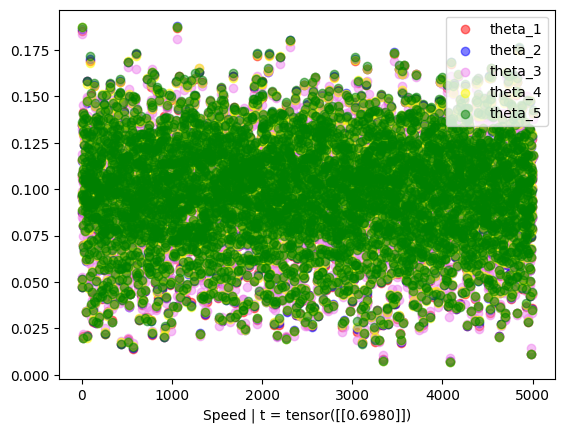

In [15]:
colors = ["red", "blue", "violet", "yellow", "green"]
for idx, speed in enumerate(speeds):
    plt.scatter(range(1, 5001), speed, alpha=0.5, label=f'theta_{idx+1}', color=colors[idx])

plt.legend()
plt.xlabel(f"Speed | t = {t}")
plt.show()

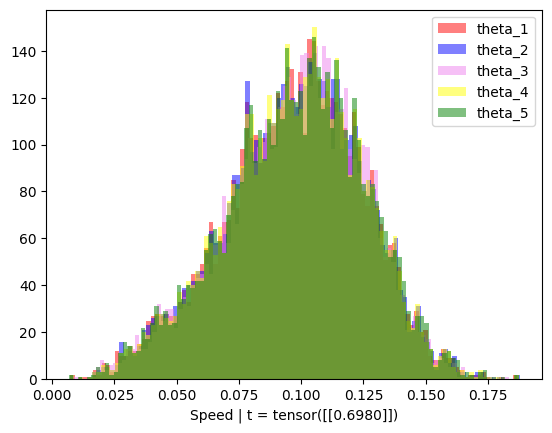

In [16]:
# colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']
colors = ["red", "blue", "violet", "yellow", "green"]
for idx, speed in enumerate(speeds):
    plt.hist(speed, bins=100, alpha=0.5, label=f'theta_{idx+1}', color=colors[idx])

plt.legend()
plt.xlabel(f"Speed | t = {t}")
plt.show()

### Direction Analysis

In [17]:
# Compare field 0 vs all others
fields = [field.detach().numpy() for field in fields]

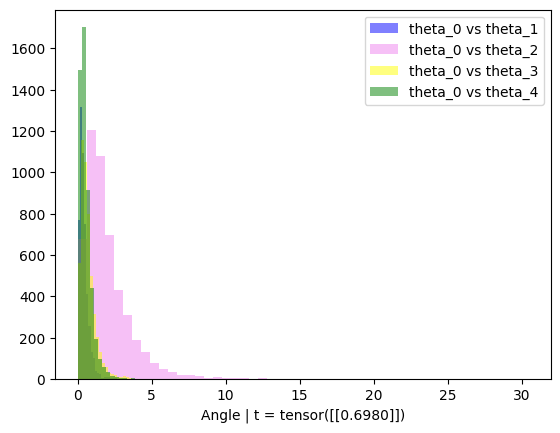

In [18]:
reference = fields[0]  # shape (5000, 3)

for idx, field in enumerate(fields[1:], 1):
    cos_sim = np.sum(reference * field, axis=1) / (
        np.linalg.norm(reference, axis=1) * np.linalg.norm(field, axis=1)
    )
    angle = np.degrees(np.arccos(np.clip(cos_sim, -1, 1)))
    plt.hist(angle, bins=50, alpha=0.5, label=f'theta_0 vs theta_{idx}', color=colors[idx])

plt.xlabel(f"Angle | t = {t}")
plt.legend()
plt.show()

### Gradient Check

In [19]:
device = torch.device("cpu")
batch_size = 1
theta_embedding = SinusoidalThetaEmbedding(32)

# Sample time and embed
t = torch.rand(size=(batch_size, 1), device=device).requires_grad_(True)
t_embedded = model.time_embedding(t)

# Unpack training data samples and construct graph:
x1 = sample.x
x0 = det_prior(x1)
mass = sample.mass.view(-1, 1)
vel = sample.vel
batch = torch.zeros(5000, dtype=int)
theta = scale_thetas(sample.theta)
node_counts_per_graph = torch.bincount(batch)
edge_index = gpu_knn_graph_pbc_batch(x1, 32, batch, device)
assert x1.shape[0] == torch.sum(node_counts_per_graph), "Number of nodes in x is different than number of halos per graph."

# Construct features
h_in = torch.ones_like(x1[:, :1])

# Sample x_t from probability path p_t
x_t = sample_xt(x0=x0, x1=x1, t=t, batch=batch) 
theta = theta.view(-1, 5).clone().detach().requires_grad_(True)
target_vel = min_image(x1 - x0, **BOX) 
pred_vel = egnn(h_in, x_t, t_embedded, batch, edge_index, theta=theta)
loss = ((pred_vel - target_vel) ** 2).mean()

# Backprop
loss.backward()

# Check gradients
print("theta grad:", theta.grad)
print("t grad:", t.grad)
print("theta grad norm:", theta.grad.norm().item())
print("t grad norm:", t.grad.norm().item())

# For comparison, also check time gradient:
# (you'd need to do the same .requires_grad_(True) trick for t_embedded)

theta grad: tensor([[ 1.9975e-05, -5.6993e-06,  3.6683e-06,  5.1993e-06, -5.7757e-06]])
t grad: tensor([[0.0077]])
theta grad norm: 2.2479798644781113e-05
t grad norm: 0.007707873359322548


In [20]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted  # pip install natsort, handles sorting "epoch_100" before "epoch_1000"

def compute_gradient_norms(model_folder, sample, device='cpu'):
    """
    For each saved model checkpoint in a folder, compute the gradient norms
    of the loss with respect to raw t and raw theta.
    """
    # Find all checkpoint files
    checkpoints = [f for f in os.listdir(model_folder) if f.endswith('.pt') or f.endswith('.pth')]
    checkpoints = natsorted(checkpoints)
    
    epochs = []
    t_norms = []
    theta_norms = []
    
    for ckpt_file in checkpoints:
        # Extract epoch number from filename - adjust this to match your naming convention
        epoch = int(''.join(filter(str.isdigit, ckpt_file)))
        
        # Load model
        ckpt_path = os.path.join(model_folder, ckpt_file)
        model = ...  # Load your model here, e.g.:
        # model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()
        
        # Setup inputs
        x1 = sample.x
        x0 = det_prior(x1)
        batch = torch.zeros(x1.shape[0], dtype=int)
        edge_index = gpu_knn_graph_pbc_batch(x1, 32, batch, device)
        h_in = torch.ones_like(x1[:, :1])
        
        # Make t and theta leaf tensors with grad
        t = torch.rand(size=(1, 1), device=device).requires_grad_(True)
        theta = scale_thetas(sample.theta).view(-1, 5).clone().detach().float().requires_grad_(True)
        
        t_embd = model.time_embedding(t)
        x_t = sample_xt(x0=x0, x1=x1, t=t, batch=batch)
        target_vel = min_image(x1 - x0, **BOX)
        
        pred_vel = model.vnet(h_in, x_t, t_embd, batch, edge_index, theta=theta)
        loss = ((pred_vel - target_vel) ** 2).mean()
        loss.backward()
        
        epochs.append(epoch)
        t_norms.append(t.grad.norm().item())
        theta_norms.append(theta.grad.norm().item())
        
        print(f"Epoch {epoch}: t_norm={t_norms[-1]:.6f}, theta_norm={theta_norms[-1]:.6f}, ratio={t_norms[-1]/theta_norms[-1]:.1f}x")
    
    return epochs, t_norms, theta_norms


def plot_gradient_norms(epochs, t_norms, theta_norms):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot raw norms
    ax1.plot(epochs, t_norms, label='t grad norm', marker='o')
    ax1.plot(epochs, theta_norms, label='θ grad norm', marker='o')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Gradient Norm')
    ax1.set_title('Raw Gradient Norms')
    ax1.set_yscale('log')
    ax1.legend()
    ax1.grid(True)
    
    # Plot ratio
    ratios = [t / th for t, th in zip(t_norms, theta_norms)]
    ax2.plot(epochs, ratios, marker='o', color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('t_norm / θ_norm')
    ax2.set_title('Gradient Norm Ratio')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('gradient_norms.png', dpi=150)
    plt.show()

### Embedding Norm Check

In [21]:
theta = scale_thetas(sample.theta).view(-1,5)
theta_embd = model.vnet.theta_embed(theta)
t = torch.tensor(0.5).view(1, 1)
t_embd = model.time_embedding(t)

print("t_embd norm:", t_embd.norm().item())
print("theta_embd norm:", theta_embd.norm().item())
print("t_embd mean abs:", t_embd.abs().mean().item())
print("theta_embd mean abs:", theta_embd.abs().mean().item())

t_embd norm: 5.656854152679443
theta_embd norm: 8.9442720413208
t_embd mean abs: 0.5255442261695862
theta_embd mean abs: 0.6541742086410522


In [22]:
theta1 = scale_thetas(torch.tensor(params_used[0, :])).view(-1, 5)
theta2 = scale_thetas(torch.tensor(params_used[-1, :])).view(-1, 5)
emb1 = model.vnet.theta_embed(theta1)
emb2 = model.vnet.theta_embed(theta2)

print("theta1:", theta1)
print("theta2:", theta2)
print("cosine similarity:", torch.nn.functional.cosine_similarity(emb1.flatten(), emb2.flatten(), dim=0).item())

theta1: tensor([[-1.0010,  0.0235,  0.9800,  0.0515,  0.6034]], dtype=torch.float64)
theta2: tensor([[0.6827, 0.6408, 0.1736, 0.3497, 0.7566]], dtype=torch.float64)
cosine similarity: 0.8061507632956909


### Embedding Checks

In [23]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, t_embd_dim):
        super().__init__()
        self.t_embd_dim = t_embd_dim

    def forward(self, t):
        # t: (batch_size, 1) — timestep values
        half = self.t_embd_dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )                                          # (half,)
        args = t * freqs                           # (batch_size, half)
        emb = torch.cat([args.sin(), args.cos()], dim=-1)  # (batch_size, t_embd_dim)
        return emb

In [24]:
sin_embd = SinusoidalTimeEmbedding(32)

t = torch.rand(4, 1)
print(t)
t_embd = sin_embd(t)
print(t_embd)

tensor([[0.9689],
        [0.3549],
        [0.4804],
        [0.4451]])
tensor([[8.2424e-01, 5.0062e-01, 2.7995e-01, 1.5295e-01, 8.3004e-02, 4.4956e-02,
         2.4334e-02, 1.3170e-02, 7.1273e-03, 3.8571e-03, 2.0874e-03, 1.1296e-03,
         6.1131e-04, 3.3082e-04, 1.7903e-04, 9.6887e-05, 5.6624e-01, 8.6566e-01,
         9.6001e-01, 9.8823e-01, 9.9655e-01, 9.9899e-01, 9.9970e-01, 9.9991e-01,
         9.9997e-01, 9.9999e-01, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00],
        [3.4746e-01, 1.9086e-01, 1.0374e-01, 5.6212e-02, 3.0431e-02, 1.6470e-02,
         8.9136e-03, 4.8238e-03, 2.6105e-03, 1.4127e-03, 7.6452e-04, 4.1374e-04,
         2.2390e-04, 1.2117e-04, 6.5573e-05, 3.5486e-05, 9.3770e-01, 9.8162e-01,
         9.9460e-01, 9.9842e-01, 9.9954e-01, 9.9986e-01, 9.9996e-01, 9.9999e-01,
         1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00],
        [4.6212e-01, 2.5705e-01, 1.4023e-01, 7.60

In [25]:
class SinusoidalThetaEmbedding(nn.Module):
    def __init__(self, theta_param_embd_dim):
        super().__init__()
        self.theta_param_embd_dim = theta_param_embd_dim

    def forward(self, theta):
        # t: (batch_size, 1) — timestep values
        N, D = theta.shape
        half = self.theta_param_embd_dim // 2
        freqs = torch.exp(
            -math.log(2) * torch.arange(half, device=theta.device) / (half - 1)
        )                                          # (half,)
        embeddings = []
        for param in range(D):
            args = theta[:, param].unsqueeze(1) * freqs        # (batch_size, half)
            emb = torch.cat([args.sin(), args.cos()], dim=-1)  # (batch_size, theta_param_embd_dim)
            embeddings.append(emb)
        return torch.cat(embeddings, dim=1)

In [26]:
sin_theta_embd = SinusoidalThetaEmbedding(32)
thetas = scale_thetas(torch.tensor(params_used))
thetas_embd = sin_theta_embd(thetas)

theta1 = thetas[0, :].view(-1, 5)
theta2 = thetas[-1, :].view(-1, 5)
emb1 = sin_theta_embd(theta1)
emb2 = sin_theta_embd(theta2)
print("theta1:", theta1)
print("theta2:", theta2)
print("cosine similarity:", torch.nn.functional.cosine_similarity(emb1.flatten(), emb2.flatten(), dim=0).item())

theta1: tensor([[-1.0010,  0.0235,  0.9800,  0.0515,  0.6034]], dtype=torch.float64)
theta2: tensor([[0.6827, 0.6408, 0.1736, 0.3497, 0.7566]], dtype=torch.float64)
cosine similarity: 0.8061507632956909


In [27]:
print(f"Embedding 1: {emb1}")
print(f"Embedding 2: {emb2}")

Embedding 1: tensor([[-0.8420, -0.8168, -0.7911, -0.7652, -0.7393, -0.7135, -0.6879, -0.6627,
         -0.6378, -0.6134, -0.5896, -0.5664, -0.5438, -0.5218, -0.5005, -0.4799,
          0.5395,  0.5770,  0.6117,  0.6437,  0.6733,  0.7006,  0.7258,  0.7489,
          0.7702,  0.7897,  0.8077,  0.8241,  0.8392,  0.8531,  0.8657,  0.8773,
          0.0235,  0.0224,  0.0214,  0.0205,  0.0195,  0.0187,  0.0178,  0.0170,
          0.0162,  0.0155,  0.0148,  0.0141,  0.0135,  0.0129,  0.0123,  0.0118,
          0.9997,  0.9997,  0.9998,  0.9998,  0.9998,  0.9998,  0.9998,  0.9999,
          0.9999,  0.9999,  0.9999,  0.9999,  0.9999,  0.9999,  0.9999,  0.9999,
          0.8305,  0.8050,  0.7793,  0.7533,  0.7275,  0.7017,  0.6763,  0.6512,
          0.6266,  0.6024,  0.5789,  0.5559,  0.5336,  0.5119,  0.4909,  0.4706,
          0.5570,  0.5932,  0.6267,  0.6576,  0.6862,  0.7124,  0.7366,  0.7589,
          0.7794,  0.7982,  0.8154,  0.8312,  0.8457,  0.8590,  0.8712,  0.8823,
          0.051